# Import Price Volatility and Nuclear Power Generation
## Cost Pressures and Energy Production in the United States

## Overview

This notebook examines how fluctuations in import prices relate to nuclear electricity generation in the United States. Import prices are used as a proxy for input cost pressures affecting large-scale infrastructure systems.

The goal is not to establish causation, but to evaluate whether cost-side macroeconomic trends align with changes in nuclear energy production.

## Research Question

How do fluctuations in import price levels relate to nuclear electricity production trends in the United States?

## Why Import Price Index?

The Import Price Index is used as a proxy for cost pressures affecting capital-intensive infrastructure projects. Nuclear energy systems require significant inputs, including machinery and specialized equipment, which are often exposed to global price dynamics.

This measure provides a more direct cost-side indicator compared to general inflation.

## Data Sources

- Import Price Index (All Commodities) – FRED
- Nuclear Electric Power Generation – FRED

| Variable | FRED Code | Description |
|--------|--------|--------|
| Nuclear Electricity Production | IPN221113N | Industrial production index (2017 = 100) |
| Import Price Index (All Commodities) | IR |   Index 2000=100, Not Seasonally Adjusted|

Both datasets are monthly and will be converted into annual measures for comparison.

## Data Frequency and Alignment

Both datasets are monthly time series. To support long-run comparison, the analysis will:

1. Convert dates to datetime format
2. Calculate year-over-year changes in import prices
3. Aggregate both series to annual averages
4. Merge datasets on a common yearly basis

In [17]:
# Packages necessary for data manipulation. 
import pandas as pd 
from pathlib import Path    

# Packages necessary for data visualization.
import matplotlib.pyplot as plt 
import seaborn as sns 

# Setting the style for plots 
sns.set_style('whitegrid')
# Setting the path to the data file.
DATA_DIR = Path("..")/"data"

# Setting up the path to the figures folder for graphs (if it doesn't exist, it will be created).
FIGURES_DIR = Path("..")/"figures"
FIGURES_DIR.mkdir(exist_ok=True)

# Loading the datasets into a data frame. 
nuclear_generation = pd.read_csv(DATA_DIR/ "IPN221113N.csv")
import_prices = pd.read_csv(DATA_DIR/ "IR.csv")

In [18]:
print(import_prices.info())
print(import_prices.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  522 non-null    str    
 1   IR                471 non-null    float64
dtypes: float64(1), str(1)
memory usage: 8.3 KB
None
    count        mean        std   min    25%    50%    75%    max
IR  471.0  113.490658  19.775066  75.0  95.75  113.7  129.2  148.5


In [19]:

import_prices['year'] = pd.to_datetime(import_prices['observation_date'])
import_prices['year'] = import_prices['year'].dt.year
import_prices = import_prices.rename(columns = {'IR': 'import_price'})
import_prices = import_prices.sort_values(by = 'observation_date')
import_prices.dropna(inplace = True)

import_prices.head(20)

,observation_date,import_price,year
0,1982-09-01,80.0,1982
3,1982-12-01,79.9,1982
6,1983-03-01,77.7,1983
9,1983-06-01,77.8,1983
12,1983-09-01,77.6,1983
15,1983-12-01,78.0,1983
18,1984-03-01,78.7,1984
21,1984-06-01,78.9,1984
24,1984-09-01,77.7,1984
27,1984-12-01,77.0,1984


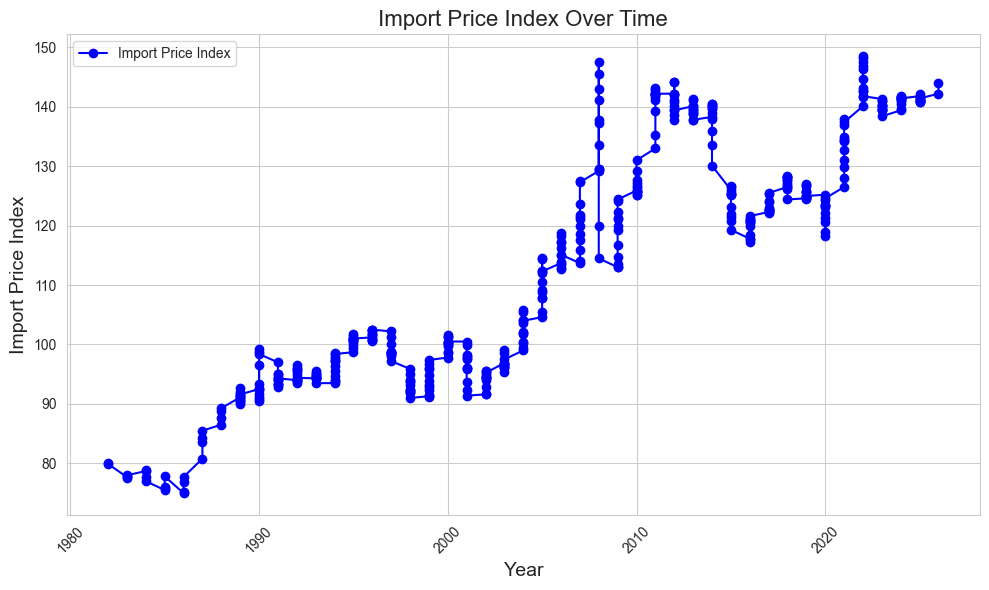

<Figure size 640x480 with 0 Axes>

In [20]:
fig, ax = plt.subplots(figsize = (10,6))

ax.plot(import_prices['year'], import_prices['import_price'], marker = 'o', color = 'blue', label = 'Import Price Index')
ax.set_title('Import Price Index Over Time', fontsize = 16)
ax.set_xlabel('Year', fontsize = 14)
ax.set_ylabel('Import Price Index', fontsize = 14)
ax.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.grid(True)
plt.show()

plt.savefig(FIGURES_DIR / "import_price_index_over_time.png")

## Sources 

1. U.S. Bureau of Labor Statistics, Import Price Index (End Use): All Commodities [IR], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/IR, March 28, 2026.

2. Board of Governors of the Federal Reserve System (US), Industrial Production: Utilities: Nuclear Electric Power Generation (NAICS = 221113) [IPN221113N], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/IPN221113N, March 18, 2026.